# Paramétrage de l'environnement de travail et import des packages

In [1]:
import sys
from pathlib import Path

In [2]:
ROOT = Path.cwd().parents[0]

MODEL_DATA = ROOT / "04_model"
PROCESSED_DATA = ROOT / "01_data" / "02_processed"

%load_ext autoreload
%autoreload 2
sys.path.append(str(ROOT / "03_fonctions"))

In [3]:
import pandas as pd
import numpy as np
import shap
from fonctions_perso.machine_learning import waterfall_plot
import joblib
from sklearn import set_config

# Interpretation - SHAP

**Import de x_test | y_test et du modèle non calibré**

In [4]:
# x_test
x_test = joblib.load(PROCESSED_DATA / "x_test_for_shap.joblib")

# y_test
y_test = joblib.load(PROCESSED_DATA / "y_test_for_shap.joblib")

# modèle
modele = joblib.load(MODEL_DATA / "fraud_detection_xgb_pas_calibre.joblib")

In [5]:
full_test = pd.concat([x_test,y_test], axis = 1)

**Initialisation**

In [6]:
set_config(transform_output="pandas")

# Appliquer toutes les étapes sans le modèle
x_test_proc = modele[:-1].transform(x_test)

In [7]:
# Récuperer le modèle "nu"
xgb = modele.named_steps["model"]

# Initialisation de l'explainer
explainer = shap.TreeExplainer(xgb, x_test_proc)

In [ ]:
shap_values = explainer(x_test_proc)

**Sauvegarde des objets**

In [ ]:
#joblib.dump(shap_values, MODEL_DATA / "shap_values_model.joblib")

['c:\\Users\\user\\Desktop\\data_science_documents\\data_science_projets_perso\\projet_fraud_detection\\fraud-detection\\04_model\\shap_values_model.joblib']

In [8]:
shap_values = joblib.load(MODEL_DATA / "shap_values_model.joblib")

**Feature Importance**

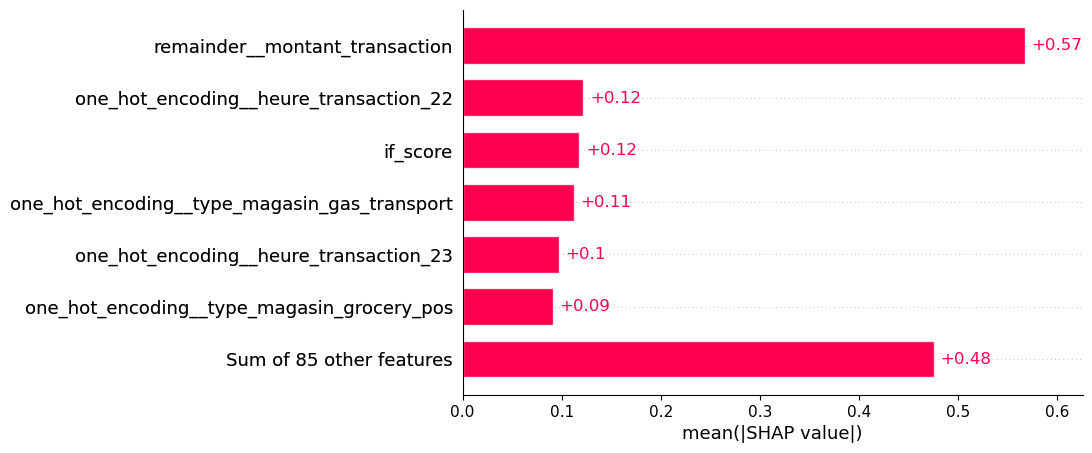

In [18]:
shap.plots.bar(shap_values, max_display=7)

**Beeswarm Plot**

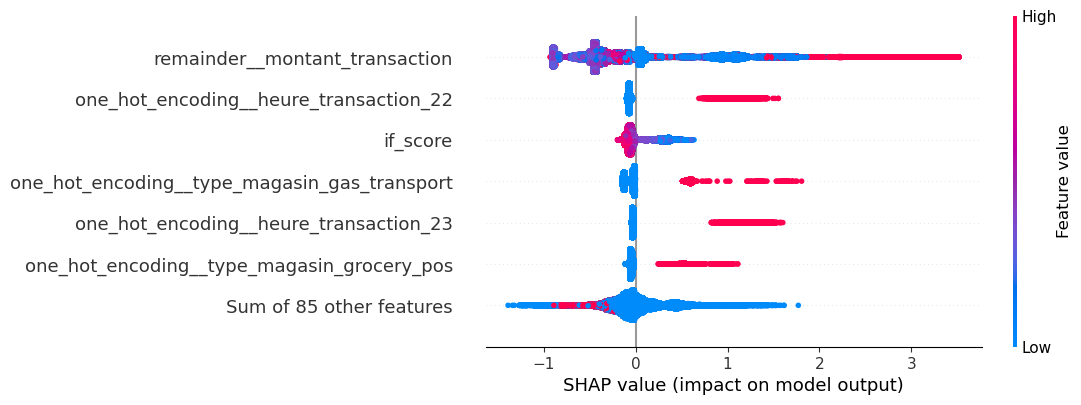

In [19]:
shap.plots.beeswarm(shap_values, max_display=7)

**Waterfall Plot**

Quelles explications pour une transaction légitime ?

In [15]:
full_test[full_test["target"]==0].sample(8)

,type_magasin,montant_transaction,etat_client,population_ville_client,heure_transaction,distance_domicile_magasin,age_client,target
364349,health_fitness,108.56,IN,137,17,113.084800,53,0
299077,misc_pos,180.08,OR,597,6,79.162704,59,0
526465,health_fitness,35.59,MN,5619,17,27.261806,61,0
404072,shopping_pos,7.23,UT,46,12,64.651325,33,0
476048,personal_care,4.07,MN,136,12,102.405232,20,0
403630,gas_transport,72.53,MT,18182,4,84.459492,45,0
361949,personal_care,19.17,LA,6581,22,43.681662,56,0
303018,personal_care,34.54,FL,105638,13,9.832328,34,0


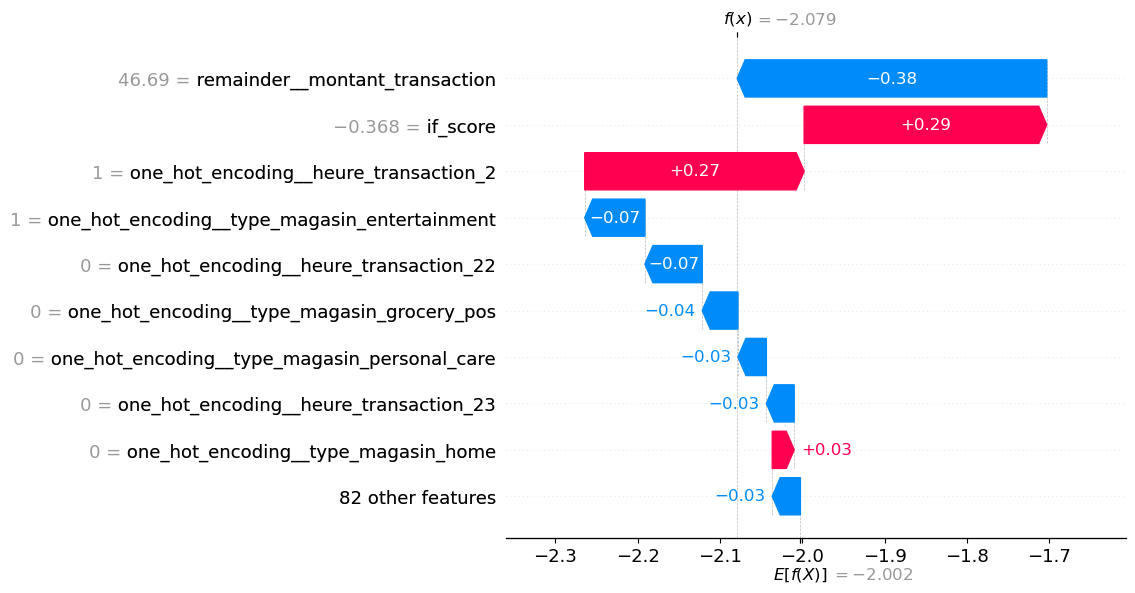

In [14]:
waterfall_plot(
    shap_values,
    x_test_proc,
    500226,
    max_display=10
)

Quelles explications pour une transaction frauduleuse ?

In [16]:
full_test[full_test["target"]==1].sample(8)

,type_magasin,montant_transaction,etat_client,population_ville_client,heure_transaction,distance_domicile_magasin,age_client,target
282204,shopping_net,1198.12,MI,96942,22,69.510881,55,1
306270,grocery_pos,298.17,TX,99,1,100.309708,55,1
333419,shopping_net,988.01,NH,5457,23,87.180762,70,1
291797,personal_care,48.13,IA,912,23,55.460590,52,1
401588,shopping_net,1070.99,OR,9587,23,99.161332,52,1
386082,grocery_pos,303.35,IN,7692,1,81.895463,34,1
307992,grocery_pos,319.10,NY,21902,2,63.515949,44,1
329471,grocery_pos,288.17,IL,3119,18,84.420891,78,1


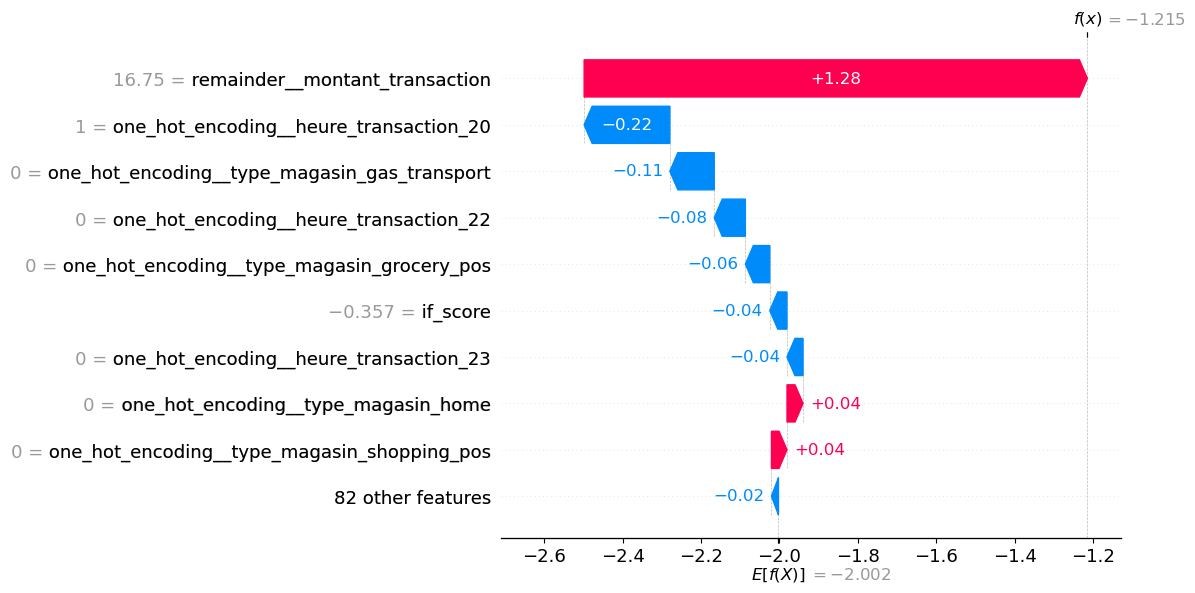

In [17]:
waterfall_plot(
    shap_values,
    x_test_proc,
    305879,
    max_display=10
)

**Interactions dans les données**

In [37]:
# x_test_proc.columns

Relation montant_transaction | if_score | probabilité de transaction frauduleuse

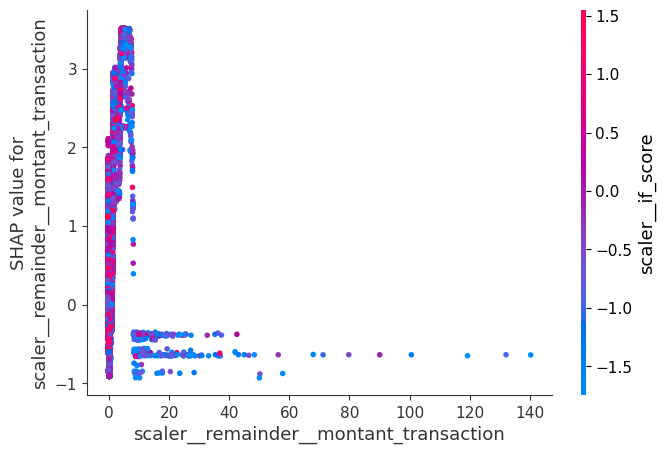

In [36]:
shap.dependence_plot(
    "scaler__remainder__montant_transaction",      
    shap_values.values,
    x_test_proc,
    interaction_index="scaler__if_score"
)

# Note explicative du Notebook 

Ce notebook analyse le comportement du modèle de détection de fraude avec SHAP à trois niveaux : importance globale des variables, effets moyens (beeswarm) et explications locales (waterfall + interactions).
### Feature importance

- La variable la plus influente est le **montant de la transaction** (`montant_transaction`), avec l’impact moyen le plus fort sur la probabilité de fraude.
- Viennent ensuite des variables de contexte :
  - l’**heure de la transaction** (22h, 23h),
  - le **score d’anomalie** `if_score` issu d’un Isolation Forest,
  - le **type de magasin** (`gas_transport`, `grocery_pos`).
- Ces variables constituent le noyau des signaux utilisés par le modèle pour distinguer transactions normales et frauduleuses.

### Beeswarm / effets moyens

- **Montant de transaction**
  - Les montants modérés ont tendance à réduire la probabilité de fraude.
  - Les montants très faibles et très élevés sont plus souvent associés à une augmentation du risque, car considérés comme atypiques.
- **Heure de transaction (22h, 23h)**
  - Ces créneaux horaires ont un impact globalement positif sur le score de fraude.
- **`if_score` (Isolation Forest)**
  - Un score faible (transaction jugée anormale) augmente la probabilité de fraude.
  - Un score élevé est plutôt associé à des transactions légitimes.
- **Type de magasin**
  - `gas_transport` a un effet globalement positif sur le risque (contexte plus sensible).
  - `grocery_pos` augmente aussi le risque, mais de façon plus modérée.

### Explications locales (Waterfall plots)

Deux transactions illustrent le fonctionnement du modèle au niveau individuel :

- **Transaction A – risque faible**
  - `if_score` bas et opération à 2h du matin tirent le score vers la fraude (contexte atypique).
  - Le montant (46.69), combiné au reste du profil, ressemble à une transaction légitime et fait baisser la probabilité de fraude.
  - Le type de magasin (entertainment) et d’autres variables contribuent à normaliser la situation.
  - Résultat : transaction classée comme peu risquée, malgré quelques signaux défavorables.

- **Transaction B – risque modéré / élevé**
  - Le montant (16.75) contribue fortement à augmenter la probabilité de fraude : dans ce contexte, ce niveau est typique des transactions frauduleuses apprises par le modèle.
  - Le reste du contexte (achat à 20h, pas en station‑service / transport, type de magasin moins sensible) réduit partiellement le risque, mais pas assez pour compenser l’effet du montant.
  - Résultat : transaction jugée modérément suspecte.

### Interactions (Dependence plot)

- L’analyse conjointe de `montant_transaction` et `if_score` montre que l’effet du montant sur le risque n’est pas linéaire.
- Des montants faibles comme élevés peuvent augmenter ou réduire la probabilité de fraude selon :
  - l’heure de la transaction,
  - le score d’anomalie,
  - le type de magasin,
  - et plus largement le profil global de la transaction.
- Les beeswarm plots et les graphiques d’interaction indiquent que le modèle ne suit pas une règle simple du type « gros montant = fraude », mais combine plusieurs dimensions du contexte pour ajuster le risque, révélant des patterns de fraude multivariés plutôt que de simples seuils univariés.
